# IMPORTACIÓN DE LIBRERÍAS
Esta celda importa todas las librerías necesarias para el proyecto.
Cada librería tiene un propósito específico en el pipeline de ML.


In [1]:
# Librerías para manipulación de datos
import pandas as pd          # Manejo de datasets CSV
import numpy as np           # Operaciones matemáticas y arrays

# PyTorch para Deep Learning
import torch                 # Framework principal de DL
import torch.nn as nn        # Módulos de redes neuronales
import torch.nn.functional as F  # Funciones de activación
import torch.optim as optim  # Optimizadores (Adam, SGD, etc.)
from torch.utils.data import DataLoader, TensorDataset  # Manejo de datos

# Scikit-learn para preprocesamiento y métricas
from sklearn.model_selection import train_test_split  # División de datos
from sklearn.preprocessing import StandardScaler      # Normalización
from sklearn.metrics import (accuracy_score, precision_score,
                           recall_score, f1_score,           # Métricas de clasificación
                           confusion_matrix, classification_report)  # Análisis detallado

# Visualización y utilidades
import matplotlib.pyplot as plt  # Gráficos
from pathlib import Path        # Manejo de rutas de archivos
import pickle                   # Guardar objetos Python (scaler)

 # CELDA 2: CONFIGURACIÓN GLOBAL DEL PROYECTO

Definimos todos los parámetros y configuraciones del proyecto.<br>
Centralizar estos valores facilita la experimentación y reproducibilidad.


In [2]:
# Configuración de directorios
DATA_DIR = Path("data")                    # Carpeta donde están los datasets
MODELS_DIR = Path("models")                # Carpeta para guardar modelos
MODELS_DIR.mkdir(exist_ok=True)           # Crear carpeta si no existe

# Hiperparámetros del modelo
SOREL_SAMPLE_SIZE = 5_000_000             # Cuántas muestras tomar de SOREL-20M
BATCH_SIZE = 4096                         # Tamaño del lote para entrenamiento
LEARNING_RATE = 0.001                     # Tasa de aprendizaje para Adam
EPOCHS = 15                               # Número máximo de epochs
RANDOM_SEED = 42                          # Semilla para reproducibilidad

# Configurar semilla para reproducibilidad
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

print("🔧 Configuración establecida:")
print(f"   📊 Muestra SOREL: {SOREL_SAMPLE_SIZE:,} registros")
print(f"   🎯 Batch size: {BATCH_SIZE}")
print(f"   📈 Learning rate: {LEARNING_RATE}")
print(f"   🔄 Epochs máximos: {EPOCHS}")

🔧 Configuración establecida:
   📊 Muestra SOREL: 5,000,000 registros
   🎯 Batch size: 4096
   📈 Learning rate: 0.001
   🔄 Epochs máximos: 15


# CELDA 3: FUNCIÓN PARA CARGAR DATASET ORIGINAL
Esta función carga y preprocesa el dataset original de 100K registros.<br>
Incluye limpieza de datos y selección de características numéricas.

In [4]:
def load_original_dataset():
    """
    Carga el dataset original de 100K registros de malware.

    Returns:
        tuple: (X, y) donde X son las características y y las etiquetas
    """
    print("📊 Cargando dataset original...")

    # Cargar archivo CSV
    df = pd.read_csv(DATA_DIR / "/Malware dataset.csv")
    print(f"   📏 Forma original: {df.shape}")

    # Crear etiquetas binarias: malware=1, benign=0
    df['label'] = (df['classification'].str.strip().str.lower() == 'malware').astype(int)

    # Mostrar distribución de clases
    class_distribution = df['label'].value_counts()
    print(f"   📊 Distribución de clases:")
    print(f"      Benign (0): {class_distribution[0]:,}")
    print(f"      Malware (1): {class_distribution[1]:,}")

    # Seleccionar solo columnas numéricas (excluir texto y hash)
    # Esto es importante porque el modelo solo puede procesar números
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols = [col for col in numeric_cols if col != 'label']  # Excluir target

    print(f"   🔢 Características numéricas seleccionadas: {len(numeric_cols)}")

    # Extraer características (X) y etiquetas (y)
    X = df[numeric_cols].values.astype(np.float32)  # Convertir a float32 para eficiencia
    y = df['label'].values.astype(np.int32)         # Etiquetas como enteros

    print(f"   ✅ Dataset procesado: X{X.shape}, y{y.shape}")
    return X, y

# Ejecutar función de carga
X_original, y_original = load_original_dataset()


📊 Cargando dataset original...
   📏 Forma original: (100000, 35)
   📊 Distribución de clases:
      Benign (0): 50,000
      Malware (1): 50,000
   🔢 Características numéricas seleccionadas: 33
   ✅ Dataset procesado: X(100000, 33), y(100000,)


# CELDA 4: FUNCIÓN PARA CARGAR MUESTRA DE SOREL-20M
Esta función implementa sampling inteligente del dataset SOREL-20M.<br>
Usa memory mapping para manejar archivos de 120GB sin saturar la RAM.

In [5]:
def load_sorel_sample():
    """
    Carga una muestra aleatoria del dataset SOREL-20M.
    Usa memory mapping para eficiencia de memoria.

    Returns:
        tuple: (X_sample, y_sample) muestra aleatoria de SOREL
    """
    print("🔍 Cargando muestra de SOREL-20M...")

    # Cargar archivos con memory mapping (no carga todo en RAM)
    # mmap_mode='r' permite acceso de solo lectura sin cargar el archivo completo
    features_path = DATA_DIR / "train-features/arr_0.npy"  # 120.9GB
    labels_path = DATA_DIR / "train-features/arr_1.npy"    # 101.6MB

    print(f"   📁 Cargando desde: {features_path}")
    features = np.load(features_path, mmap_mode='r')       # Memory mapping
    labels = np.load(labels_path, mmap_mode='r')

    print(f"   📏 SOREL completo: {features.shape}")
    print(f"   🎯 Muestra a extraer: {SOREL_SAMPLE_SIZE:,}")

    # Generar índices aleatorios para sampling
    # replace=False asegura que no hay duplicados
    total_samples = len(features)
    if SOREL_SAMPLE_SIZE > total_samples:
        print(f"   ⚠️  Ajustando muestra a {total_samples:,} (total disponible)")
        sample_size = total_samples
    else:
        sample_size = SOREL_SAMPLE_SIZE

    indices = np.random.choice(total_samples, sample_size, replace=False)
    print(f"   🎲 Índices aleatorios generados: {len(indices):,}")

    # Preparar arrays para almacenar la muestra
    n_features = features.shape[1]
    X_sample = np.zeros((sample_size, n_features), dtype=np.float32)
    y_sample = np.zeros(sample_size, dtype=np.int32)

    # Cargar datos por chunks para no saturar la memoria
    # Esto es crucial cuando trabajamos con archivos de 120GB
    chunk_size = 100_000
    print(f"   📦 Cargando por chunks de {chunk_size:,}...")

    for i in range(0, len(indices), chunk_size):
        # Calcular rango del chunk actual
        end_idx = min(i + chunk_size, len(indices))
        chunk_indices = indices[i:end_idx]

        # Cargar chunk desde los archivos memory-mapped
        X_sample[i:end_idx] = features[chunk_indices]
        y_sample[i:end_idx] = labels[chunk_indices]

        # Mostrar progreso cada 10 chunks
        if (i // chunk_size + 1) % 10 == 0:
            progress = (end_idx / len(indices)) * 100
            print(f"      📈 Progreso: {progress:.1f}%")

    # Verificar distribución de clases en la muestra
    unique, counts = np.unique(y_sample, return_counts=True)
    print(f"   📊 Distribución en muestra SOREL:")
    for label, count in zip(unique, counts):
        label_name = "Malware" if label == 1 else "Benign"
        percentage = (count / len(y_sample)) * 100
        print(f"      {label_name} ({label}): {count:,} ({percentage:.1f}%)")

    print(f"   ✅ Muestra SOREL cargada: X{X_sample.shape}, y{y_sample.shape}")
    return X_sample, y_sample

# Ejecutar función de carga SOREL
X_sorel, y_sorel = load_sorel_sample()


🔍 Cargando muestra de SOREL-20M...
   📁 Cargando desde: data/train-features/arr_0.npy


FileNotFoundError: [Errno 2] No such file or directory: 'data/train-features/arr_0.npy'

# CELDA 5: COMBINACIÓN DE DATASETS

Combinamos el dataset original con la muestra de SOREL para crear<br>
un dataset híbrido más robusto y diverso.<br>
IMPORTANTE: Manejamos diferencias en el número de características.

In [ ]:
print("🔗 Combinando datasets...")

# Verificar dimensiones antes de combinar
print(f"📊 Dimensiones antes de combinar:")
print(f"   Dataset original: {X_original.shape} ({X_original.shape[1]} características)")
print(f"   SOREL sample: {X_sorel.shape} ({X_sorel.shape[1]} características)")

# Manejar diferencias en número de características
if X_original.shape[1] == X_sorel.shape[1]:
    print("✅ Mismas dimensiones - Combinación directa")
    X_combined = np.vstack([X_original, X_sorel])

elif X_original.shape[1] < X_sorel.shape[1]:
    print("🔧 Dataset original tiene menos características - Aplicando padding")
    # Añadir columnas de ceros al dataset original para igualar dimensiones
    n_missing_features = X_sorel.shape[1] - X_original.shape[1]
    padding = np.zeros((X_original.shape[0], n_missing_features), dtype=np.float32)
    X_original_padded = np.hstack([X_original, padding])

    print(f"   📏 Padding añadido: {n_missing_features} características")
    print(f"   📊 Nueva forma original: {X_original_padded.shape}")

    # Ahora sí se pueden combinar
    X_combined = np.vstack([X_original_padded, X_sorel])

elif X_original.shape[1] > X_sorel.shape[1]:
    print("🔧 SOREL tiene menos características - Aplicando padding a SOREL")
    # Añadir columnas de ceros a SOREL para igualar dimensiones
    n_missing_features = X_original.shape[1] - X_sorel.shape[1]
    padding = np.zeros((X_sorel.shape[0], n_missing_features), dtype=np.float32)
    X_sorel_padded = np.hstack([X_sorel, padding])

    print(f"   📏 Padding añadido a SOREL: {n_missing_features} características")
    print(f"   📊 Nueva forma SOREL: {X_sorel_padded.shape}")

    # Ahora sí se pueden combinar
    X_combined = np.vstack([X_original, X_sorel_padded])

# Combinar etiquetas (esto siempre funciona)
y_combined = np.hstack([y_original, y_sorel])

print(f"📊 Dataset híbrido creado:")
print(f"   📏 Forma final: {X_combined.shape}")
print(f"   🔢 Total registros: {X_combined.shape[0]:,}")
print(f"   📋 Características: {X_combined.shape[1]:,}")

# Analizar distribución final
unique_final, counts_final = np.unique(y_combined, return_counts=True)
print(f"   📊 Distribución final del dataset híbrido:")
for label, count in zip(unique_final, counts_final):
    label_name = "Malware" if label == 1 else "Benign"
    percentage = (count / len(y_combined)) * 100
    print(f"      {label_name}: {count:,} ({percentage:.1f}%)")

# Liberar memoria de arrays individuales
del X_original, X_sorel, y_original, y_sorel
print("   🧹 Memoria liberada de datasets individuales")

🔗 Combinando datasets...
📊 Dimensiones antes de combinar:
   Dataset original: (100000, 33) (33 características)
   SOREL sample: (5000000, 2381) (2381 características)
🔧 Dataset original tiene menos características - Aplicando padding
   📏 Padding añadido: 2348 características
   📊 Nueva forma original: (100000, 2381)
📊 Dataset híbrido creado:
   📏 Forma final: (5100000, 2381)
   🔢 Total registros: 5,100,000
   📋 Características: 2,381
   📊 Distribución final del dataset híbrido:
      Benign: 2,057,760 (40.3%)
      Malware: 3,042,240 (59.7%)
   🧹 Memoria liberada de datasets individuales



# CELDA 6: DIVISIÓN DE DATOS (TRAIN/VALIDATION/TEST)


Dividimos el dataset en tres conjuntos:<br>
- Train (70%): Para entrenar el modelo<br>
- Validation (15%): Para validar durante entrenamiento y hacer early stopping<br>
- Test (15%): Para evaluación final (nunca visto durante entrenamiento)


In [ ]:
print("✂️ Dividiendo dataset en Train/Validation/Test...")

# Primera división: separar test set (15%)
# stratify=y_combined mantiene la proporción de clases en ambos conjuntos
X_temp, X_test, y_temp, y_test = train_test_split(
    X_combined, y_combined,
    test_size=0.15,           # 15% para test
    random_state=RANDOM_SEED, # Para reproducibilidad
    stratify=y_combined       # Mantener proporción de clases
)

# Segunda división: separar train y validation del 85% restante
# test_size=0.176 porque 0.176 * 0.85 ≈ 0.15 (15% del total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.176,          # ~15% del dataset total
    random_state=RANDOM_SEED,
    stratify=y_temp
)

print(f"📊 División completada:")
print(f"   🏋️  Train:      {len(X_train):,} registros ({len(X_train)/len(X_combined)*100:.1f}%)")
print(f"   📏 Validation: {len(X_val):,} registros ({len(X_val)/len(X_combined)*100:.1f}%)")
print(f"   🧪 Test:       {len(X_test):,} registros ({len(X_test)/len(X_combined)*100:.1f}%)")

# Verificar que las proporciones de clases se mantienen
for name, y_set in [("Train", y_train), ("Validation", y_val), ("Test", y_test)]:
    malware_pct = (y_set == 1).mean() * 100
    print(f"      {name}: {malware_pct:.1f}% malware")

# Liberar dataset combinado para ahorrar memoria
del X_combined, y_combined, X_temp, y_temp
print("   🧹 Memoria liberada de dataset combinado")

✂️ Dividiendo dataset en Train/Validation/Test...
📊 División completada:
   🏋️  Train:      3,572,040 registros (70.0%)
   📏 Validation: 762,960 registros (15.0%)
   🧪 Test:       765,000 registros (15.0%)
      Train: 59.7% malware
      Validation: 59.7% malware
      Test: 59.7% malware
   🧹 Memoria liberada de dataset combinado


# CELDA 7: NORMALIZACIÓN DE CARACTERÍSTICAS

Normalizamos las características para que tengan media=0 y desviación estándar=1.<br>
Esto es crucial para el entrenamiento eficiente de redes neuronales.


In [ ]:
print("⚖️ Normalizando características...")

# Crear scaler y ajustarlo SOLO con datos de entrenamiento
# Esto es importante para evitar data leakage
scaler = StandardScaler()
print("   📊 Calculando estadísticas de normalización con train set...")

# fit_transform: calcula media y std del train set Y transforma
X_train_scaled = scaler.fit_transform(X_train)

# transform: solo transforma usando estadísticas del train set
# NO calcula nuevas estadísticas para evitar data leakage
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("   ✅ Normalización completada")
print(f"      📈 Media train antes: {X_train.mean():.3f}")
print(f"      📈 Media train después: {X_train_scaled.mean():.3f}")
print(f"      📊 Std train antes: {X_train.std():.3f}")
print(f"      📊 Std train después: {X_train_scaled.std():.3f}")

# Guardar el scaler para uso futuro (inferencia en producción)
scaler_path = MODELS_DIR / "scaler.pkl"
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f"   💾 Scaler guardado en: {scaler_path}")

# Liberar arrays sin normalizar
del X_train, X_val, X_test
print("   🧹 Arrays originales liberados de memoria")


⚖️ Normalizando características...
   📊 Calculando estadísticas de normalización con train set...
   ✅ Normalización completada
      📈 Media train antes: 5023703040.000
      📈 Media train después: -0.000


/home/labtecnologiasemergentes/anaconda3/envs/ShadowNet_Defender/lib/python3.11/site-packages/numpy/_core/_methods.py:204: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(x, axis, dtype, out, keepdims=keepdims, where=where)


      📊 Std train antes: inf
      📊 Std train después: 0.991
   💾 Scaler guardado en: models/scaler.pkl
   🧹 Arrays originales liberados de memoria


# CELDA 8: CREACIÓN DE DATALOADERS

Los DataLoaders manejan el batching, shuffling y carga de datos durante el entrenamiento. <b>
Son esenciales para entrenar con datasets grandes.

In [ ]:
print("📦 Creando DataLoaders...")

# Convertir arrays NumPy a tensores PyTorch
# Float32 es más eficiente que Float64 para entrenamiento
print("   🔄 Convirtiendo a tensores PyTorch...")
train_X_tensor = torch.FloatTensor(X_train_scaled)
train_y_tensor = torch.FloatTensor(y_train).unsqueeze(1)  # Añadir dimensión para BCELoss

val_X_tensor = torch.FloatTensor(X_val_scaled)
val_y_tensor = torch.FloatTensor(y_val).unsqueeze(1)

test_X_tensor = torch.FloatTensor(X_test_scaled)
test_y_tensor = torch.FloatTensor(y_test).unsqueeze(1)

# Crear TensorDatasets (agrupa características y etiquetas)
train_dataset = TensorDataset(train_X_tensor, train_y_tensor)
val_dataset = TensorDataset(val_X_tensor, val_y_tensor)
test_dataset = TensorDataset(test_X_tensor, test_y_tensor)

# Configurar pin_memory según disponibilidad de GPU
use_pin_memory = torch.cuda.is_available()

# Crear DataLoaders
# shuffle=True para train (mezcla datos cada epoch)
# shuffle=False para val/test (orden no importa)
# num_workers=4 para carga paralela de datos
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,           # Mezclar datos cada epoch
    num_workers=4,          # Carga paralela
    pin_memory=use_pin_memory  # Solo True si hay GPU
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE * 2,  # Batch más grande para validación (no hay backprop)
    shuffle=False,
    num_workers=4,
    pin_memory=use_pin_memory  # Solo True si hay GPU
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE * 2,
    shuffle=False,
    num_workers=4,
    pin_memory=use_pin_memory  # Solo True si hay GPU
)

print("   ✅ DataLoaders creados:")
print(f"      🏋️  Train batches: {len(train_loader):,}")
print(f"      📏 Val batches: {len(val_loader):,}")
print(f"      🧪 Test batches: {len(test_loader):,}")

# Liberar arrays escalados para ahorrar memoria
del X_train_scaled, X_val_scaled, X_test_scaled
del train_X_tensor, train_y_tensor, val_X_tensor, val_y_tensor, test_X_tensor, test_y_tensor
print("   🧹 Arrays escalados liberados de memoria")

📦 Creando DataLoaders...
   🔄 Convirtiendo a tensores PyTorch...
   ✅ DataLoaders creados:
      🏋️  Train batches: 873
      📏 Val batches: 94
      🧪 Test batches: 94
   🧹 Arrays escalados liberados de memoria


# CELDA 9: DEFINICIÓN DEL MODELO

Definimos la arquitectura de la red neuronal para detección de malware.<b>
Es un Multi-Layer Perceptron (MLP) con 4 capas lineales y regularización.

In [ ]:
class MalwareDetector(nn.Module):
    """
    Red neuronal feed-forward para clasificación binaria de malware.

    Arquitectura:
    - Input Layer: input_dim → 512 neuronas
    - Hidden Layer 1: 512 → 256 neuronas
    - Hidden Layer 2: 256 → 128 neuronas
    - Output Layer: 128 → 1 neurona (probabilidad)

    Regularización:
    - Batch Normalization en cada capa para estabilidad
    - Dropout decreciente (30% → 20% → 10%) para prevenir overfitting
    - ReLU como función de activación (evita vanishing gradients)
    - Sigmoid en salida para convertir a probabilidad (0-1)
    """

    def __init__(self, input_dim):
        """
        Inicializa la arquitectura del modelo.

        Args:
            input_dim (int): Número de características de entrada
        """
        super(MalwareDetector, self).__init__()

        # Definir todas las capas usando nn.Sequential para simplificar
        self.layers = nn.Sequential(
            # CAPA 1: Input → 512 neuronas
            nn.Linear(input_dim, 512),      # Transformación lineal
            nn.BatchNorm1d(512),            # Normalización por lotes
            nn.ReLU(),                      # Función de activación ReLU
            nn.Dropout(0.3),                # Dropout 30%

            # CAPA 2: 512 → 256 neuronas
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),                # Dropout 20% (menos que anterior)

            # CAPA 3: 256 → 128 neuronas
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.1),                # Dropout 10% (menos que anterior)

            # CAPA 4: 128 → 1 neurona (salida)
            nn.Linear(128, 1),
            nn.Sigmoid()                    # Sigmoid para probabilidad [0,1]
        )

    def forward(self, x):
        """
        Forward pass del modelo.

        Args:
            x (torch.Tensor): Batch de características de entrada

        Returns:
            torch.Tensor: Probabilidades de ser malware [0,1]
        """
        return self.layers(x)

    def get_num_params(self):
        """Retorna el número total de parámetros del modelo."""
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

# Crear instancia del modelo
# input_dim es el número de características del dataset
input_dim = train_dataset[0][0].shape[0]  # Obtener dimensión del primer ejemplo
model = MalwareDetector(input_dim)

print("🧠 Modelo creado:")
print(f"   📏 Dimensión de entrada: {input_dim:,} características")
print(f"   🔢 Parámetros entrenables: {model.get_num_params():,}")
print(f"   🏗️  Arquitectura:")
print(f"      Input  → 512 → 256 → 128 → 1")
print(f"      ReLU + BatchNorm + Dropout en cada capa")

🧠 Modelo creado:
   📏 Dimensión de entrada: 2,381 características
   🔢 Parámetros entrenables: 1,385,729
   🏗️  Arquitectura:
      Input  → 512 → 256 → 128 → 1
      ReLU + BatchNorm + Dropout en cada capa


# CELDA 10: CONFIGURACIÓN DE ENTRENAMIENTO

Configuramos los componentes necesarios para el entrenamiento:<br>
- Función de pérdida, optimizador y scheduler<br>
- Detección de GPU y configuración de dispositivo



In [ ]:
# Detectar dispositivo disponible (GPU vs CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🔥 Dispositivo seleccionado: {device}")

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_memory = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"   🎮 GPU: {gpu_name}")
    print(f"   💾 Memoria GPU: {gpu_memory:.1f} GB")
else:
    print("   💻 Ejecutando en CPU")

# Mover modelo al dispositivo
model = model.to(device)
print("   ✅ Modelo movido al dispositivo")

# Función de pérdida para clasificación binaria
# BCELoss (Binary Cross-Entropy) es ideal para clasificación binaria
criterion = nn.BCELoss()

# Optimizador Adam con weight decay para regularización L2
# Adam combina momentum y adaptive learning rates
optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,     # Learning rate inicial
    weight_decay=1e-5     # Regularización L2 (previene overfitting)
)

# Scheduler para reducir learning rate cuando se estanque
# Reduce LR por factor de 0.5 si no mejora por 3 epochs
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',           # Minimizar la métrica (validation loss)
    patience=3,           # Epochs a esperar antes de reducir LR
    factor=0.5,           # Factor de reducción (LR = LR * 0.5)
    #verbose=True          # Imprimir cuando se reduzca LR
)

print("⚙️ Configuración de entrenamiento:")
print(f"   📉 Función de pérdida: Binary Cross-Entropy")
print(f"   🎯 Optimizador: Adam (lr={LEARNING_RATE}, weight_decay=1e-5)")
print(f"   📈 Scheduler: ReduceLROnPlateau (patience=3, factor=0.5)")

🔥 Dispositivo seleccionado: cpu
   💻 Ejecutando en CPU
   ✅ Modelo movido al dispositivo
⚙️ Configuración de entrenamiento:
   📉 Función de pérdida: Binary Cross-Entropy
   🎯 Optimizador: Adam (lr=0.001, weight_decay=1e-5)
   📈 Scheduler: ReduceLROnPlateau (patience=3, factor=0.5)


# CELDA 11: FUNCIÓN DE ENTRENAMIENTO

Implementa el loop principal de entrenamiento con validación y early stopping.

In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, device, epochs):
    """
    Entrena el modelo de detección de malware.

    Args:
        model: Modelo a entrenar
        train_loader: DataLoader de entrenamiento
        val_loader: DataLoader de validación
        criterion: Función de pérdida
        optimizer: Optimizador
        scheduler: Scheduler de learning rate
        device: Dispositivo (CPU/GPU)
        epochs: Número máximo de epochs

    Returns:
        tuple: (train_losses, val_losses, val_accuracies) histórico de métricas
    """

    # Variables para tracking del entrenamiento
    train_losses = []       # Pérdida de entrenamiento por epoch
    val_losses = []         # Pérdida de validación por epoch
    val_accuracies = []     # Accuracy de validación por epoch

    # Variables para early stopping
    best_val_loss = float('inf')    # Mejor pérdida de validación
    patience_counter = 0            # Contador para early stopping
    patience_limit = 5              # Máximo de epochs sin mejora

    print(f"🏋️ Iniciando entrenamiento por {epochs} epochs...")
    print("=" * 60)

    for epoch in range(epochs):
        # ========== FASE DE ENTRENAMIENTO ==========
        model.train()  # Activar modo entrenamiento (dropout y batchnorm activos)
        train_loss = 0.0
        train_samples = 0

        for batch_idx, (X_batch, y_batch) in enumerate(train_loader):
            # Mover datos al dispositivo (GPU/CPU)
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            # Forward pass: pasar datos por el modelo
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            # Backward pass: calcular gradientes
            optimizer.zero_grad()  # Limpiar gradientes previos
            loss.backward()        # Backpropagation
            optimizer.step()       # Actualizar pesos

            # Acumular estadísticas
            train_loss += loss.item() * X_batch.size(0)
            train_samples += X_batch.size(0)

        # Calcular pérdida promedio de entrenamiento
        avg_train_loss = train_loss / train_samples

        # ========== FASE DE VALIDACIÓN ==========
        model.eval()  # Activar modo evaluación (dropout off, batchnorm fixed)
        val_loss = 0.0
        val_correct = 0
        val_samples = 0

        # No calcular gradientes durante validación (más eficiente)
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                # Forward pass solamente
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)

                # Calcular predicciones (probabilidad >= 0.5 → malware)
                predictions = (outputs >= 0.5).float()

                # Acumular estadísticas
                val_loss += loss.item() * X_batch.size(0)
                val_correct += (predictions == y_batch).sum().item()
                val_samples += X_batch.size(0)

        # Calcular métricas de validación
        avg_val_loss = val_loss / val_samples
        val_accuracy = val_correct / val_samples

        # Guardar métricas del epoch
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        val_accuracies.append(val_accuracy)

        # Actualizar learning rate basado en validation loss
        scheduler.step(avg_val_loss)
        current_lr = optimizer.param_groups[0]['lr']

        # Imprimir progreso
        print(f"Epoch {epoch+1:2d}/{epochs}: "
              f"Train Loss: {avg_train_loss:.4f}, "
              f"Val Loss: {avg_val_loss:.4f}, "
              f"Val Acc: {val_accuracy:.4f}, "
              f"LR: {current_lr:.6f}")

        # ========== EARLY STOPPING Y GUARDADO ==========
        if avg_val_loss < best_val_loss:
            # Nueva mejor pérdida: guardar modelo y resetear contador
            best_val_loss = avg_val_loss
            patience_counter = 0

            # Guardar el mejor modelo
            model_path = MODELS_DIR / "best_model.pth"
            torch.save(model.state_dict(), model_path)
            print(f"   💾 Mejor modelo guardado! (Val Loss: {best_val_loss:.4f})")

        else:
            # No hubo mejora: incrementar contador
            patience_counter += 1
            print(f"   ⏳ Sin mejora por {patience_counter} epochs")

            # Si se agotó la paciencia: early stopping
            if patience_counter >= patience_limit:
                print(f"   ⏹️ Early stopping activado después de {epoch+1} epochs")
                print(f"   🏆 Mejor validation loss: {best_val_loss:.4f}")
                break

    print("=" * 60)
    print("✅ Entrenamiento completado")

    return train_losses, val_losses, val_accuracies

# Ejecutar entrenamiento
train_losses, val_losses, val_accuracies = train_model(
    model, train_loader, val_loader, criterion, optimizer, scheduler, device, EPOCHS
)

🏋️ Iniciando entrenamiento por 15 epochs...
Epoch  1/15: Train Loss: 0.1176, Val Loss: 0.0905, Val Acc: 0.9661, LR: 0.001000
   💾 Mejor modelo guardado! (Val Loss: 0.0905)
Epoch  2/15: Train Loss: 0.0832, Val Loss: 0.2239, Val Acc: 0.8996, LR: 0.001000
   ⏳ Sin mejora por 1 epochs
Epoch  3/15: Train Loss: 0.0763, Val Loss: 0.1906, Val Acc: 0.9153, LR: 0.001000
   ⏳ Sin mejora por 2 epochs
Epoch  4/15: Train Loss: 0.0715, Val Loss: 0.0594, Val Acc: 0.9787, LR: 0.001000
   💾 Mejor modelo guardado! (Val Loss: 0.0594)
Epoch  5/15: Train Loss: 0.0678, Val Loss: 0.4507, Val Acc: 0.7777, LR: 0.001000
   ⏳ Sin mejora por 1 epochs
Epoch  6/15: Train Loss: 0.0654, Val Loss: 0.0570, Val Acc: 0.9795, LR: 0.001000
   💾 Mejor modelo guardado! (Val Loss: 0.0570)
Epoch  7/15: Train Loss: 0.0638, Val Loss: 0.8269, Val Acc: 0.6662, LR: 0.001000
   ⏳ Sin mejora por 1 epochs
Epoch  8/15: Train Loss: 0.0622, Val Loss: 0.7682, Val Acc: 0.6071, LR: 0.001000
   ⏳ Sin mejora por 2 epochs
Epoch  9/15: Train Los

# CELDA 12: FUNCIÓN DE EVALUACIÓN

Evalúa el modelo entrenado en el conjunto de test y calcula métricas completas.

In [ ]:
def evaluate_model(model, test_loader, device):
    """
    Evalúa el modelo en el conjunto de test.

    Args:
        model: Modelo entrenado
        test_loader: DataLoader del conjunto de test
        device: Dispositivo (CPU/GPU)

    Returns:
        dict: Diccionario con todas las métricas calculadas
    """
    print("🧪 Evaluando modelo en conjunto de test...")

    # Cargar el mejor modelo guardado
    model.load_state_dict(torch.load(MODELS_DIR / "best_model.pth"))
    model.eval()  # Modo evaluación

    # Listas para almacenar todas las predicciones y targets
    all_predictions = []
    all_targets = []
    all_probabilities = []  # Para análisis adicional

    # Evaluar sin calcular gradientes
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)

            # Forward pass
            outputs = model(X_batch)  # Probabilidades [0,1]
            predictions = (outputs >= 0.5).float()  # Conversión a predicciones binarias

            # Guardar resultados (mover a CPU para métricas)
            all_predictions.extend(predictions.cpu().numpy())
            all_targets.extend(y_batch.numpy())
            all_probabilities.extend(outputs.cpu().numpy())

    # Convertir a arrays NumPy
    y_true = np.array(all_targets).flatten()
    y_pred = np.array(all_predictions).flatten()
    y_proba = np.array(all_probabilities).flatten()

    # Calcular métricas de clasificación
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    # Métricas adicionales
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp)  # True Negative Rate

    print("📊 Métricas calculadas en conjunto de test:")
    print(f"   🎯 Accuracy:    {accuracy:.4f}")
    print(f"   🎯 Precision:   {precision:.4f}")
    print(f"   🎯 Recall:      {recall:.4f}")
    print(f"   🎯 F1-Score:    {f1:.4f}")
    print(f"   🎯 Specificity: {specificity:.4f}")

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'specificity': specificity,
        'y_true': y_true,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'confusion_matrix': confusion_matrix(y_true, y_pred)
    }

# Ejecutar evaluación
results = evaluate_model(model, test_loader, device)

🧪 Evaluando modelo en conjunto de test...
📊 Métricas calculadas en conjunto de test:
   🎯 Accuracy:    0.9815
   🎯 Precision:   0.9870
   🎯 Recall:      0.9820
   🎯 F1-Score:    0.9845
   🎯 Specificity: 0.9808


# CELDA 13: VISUALIZACIÓN DE RESULTADOS

Genera gráficos comprehensivos de los resultados del entrenamiento y evaluación.

/tmp/ipykernel_1000934/1329885357.py:92: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/home/labtecnologiasemergentes/anaconda3/envs/ShadowNet_Defender/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


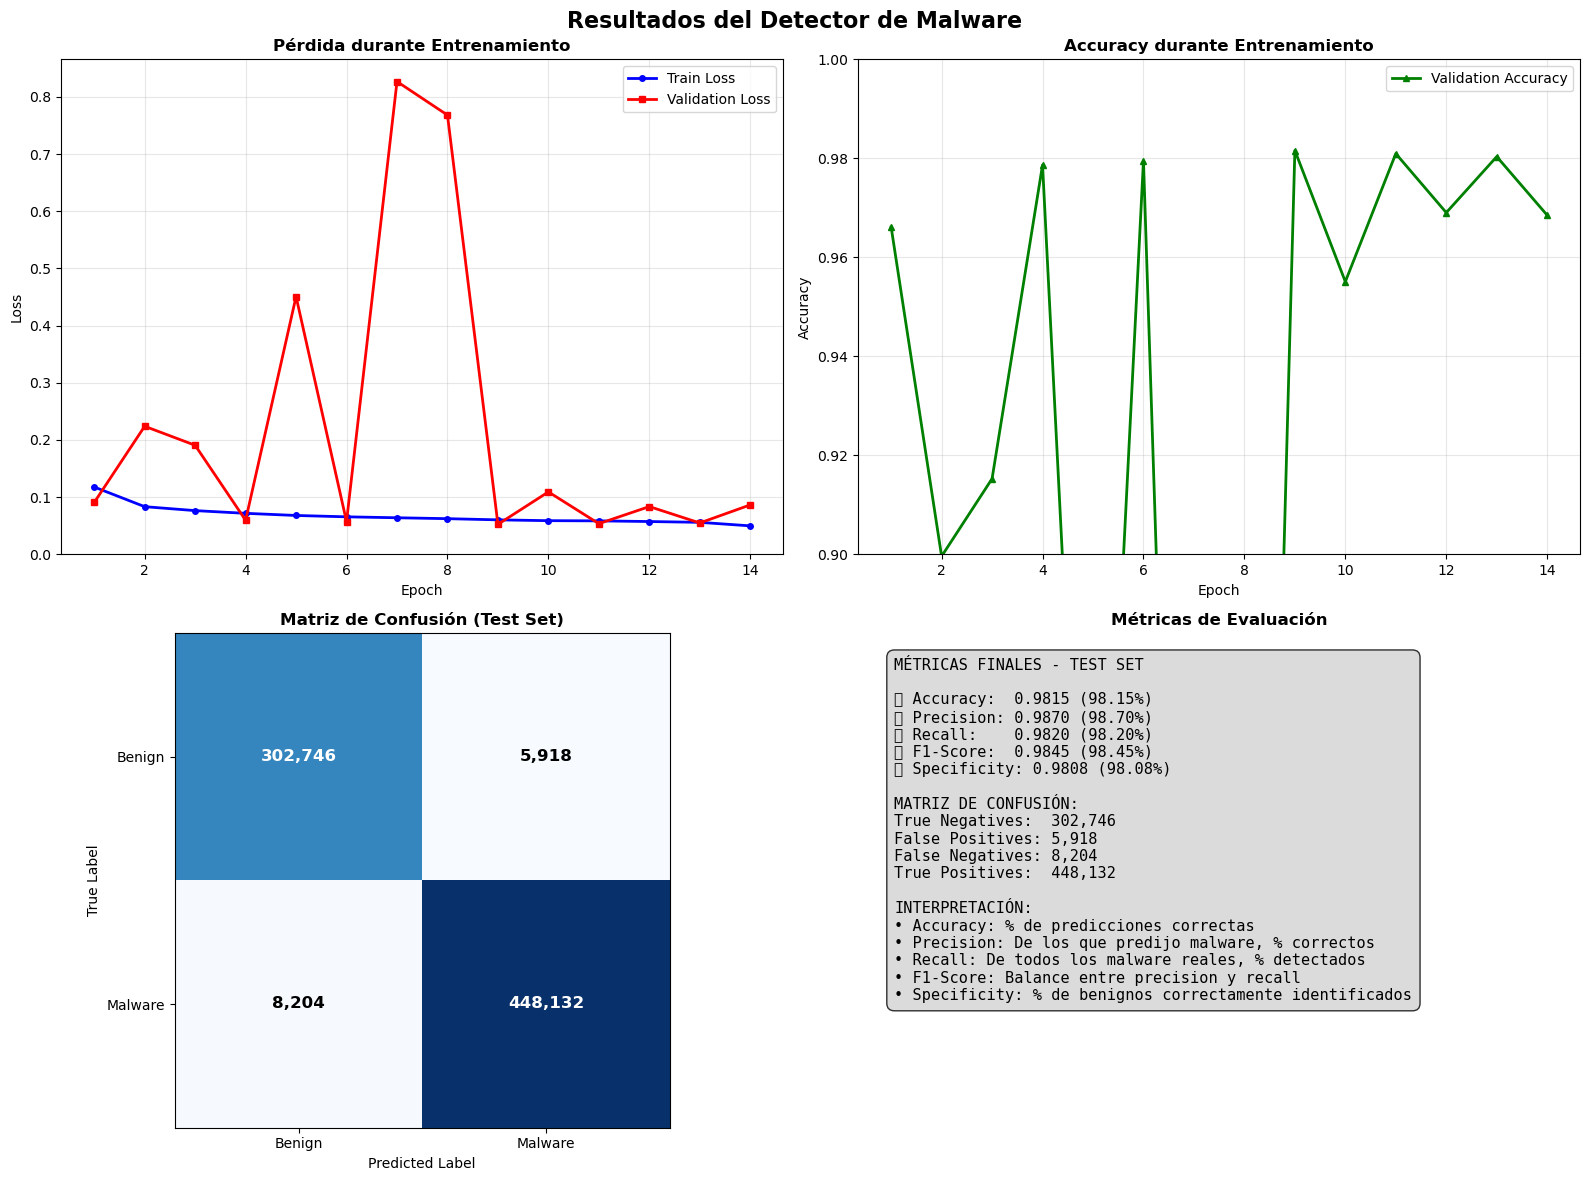

/tmp/ipykernel_1000934/1329885357.py:96: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans Mono.
  fig.savefig(MODELS_DIR / 'training_results.png', dpi=300, bbox_inches='tight')


📊 Gráficos guardados en: models/training_results.png


In [ ]:
def plot_results(train_losses, val_losses, val_accuracies, results):
    """
    Genera visualizaciones comprehensivas de los resultados.

    Args:
        train_losses: Lista de pérdidas de entrenamiento
        val_losses: Lista de pérdidas de validación
        val_accuracies: Lista de accuracies de validación
        results: Diccionario con resultados de evaluación
    """

    # Configurar figura con subplots
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Resultados del Detector de Malware', fontsize=16, fontweight='bold')

    # ========== GRÁFICO 1: PÉRDIDAS DE ENTRENAMIENTO ==========
    axes[0,0].plot(range(1, len(train_losses)+1), train_losses,
                   label='Train Loss', color='blue', linewidth=2, marker='o', markersize=4)
    axes[0,0].plot(range(1, len(val_losses)+1), val_losses,
                   label='Validation Loss', color='red', linewidth=2, marker='s', markersize=4)
    axes[0,0].set_title('Pérdida durante Entrenamiento', fontweight='bold')
    axes[0,0].set_xlabel('Epoch')
    axes[0,0].set_ylabel('Loss')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)
    axes[0,0].set_ylim(bottom=0)

    # ========== GRÁFICO 2: ACCURACY DE VALIDACIÓN ==========
    axes[0,1].plot(range(1, len(val_accuracies)+1), val_accuracies,
                   label='Validation Accuracy', color='green', linewidth=2, marker='^', markersize=4)
    axes[0,1].set_title('Accuracy durante Entrenamiento', fontweight='bold')
    axes[0,1].set_xlabel('Epoch')
    axes[0,1].set_ylabel('Accuracy')
    axes[0,1].legend()
    axes[0,1].grid(True, alpha=0.3)
    axes[0,1].set_ylim(0.9, 1.0)  # Zoom a rango relevante

    # ========== GRÁFICO 3: MATRIZ DE CONFUSIÓN ==========
    cm = results['confusion_matrix']
    im = axes[1,0].imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    axes[1,0].set_title('Matriz de Confusión (Test Set)', fontweight='bold')

    # Configurar labels
    class_names = ['Benign', 'Malware']
    tick_marks = np.arange(len(class_names))
    axes[1,0].set_xticks(tick_marks)
    axes[1,0].set_yticks(tick_marks)
    axes[1,0].set_xticklabels(class_names)
    axes[1,0].set_yticklabels(class_names)
    axes[1,0].set_xlabel('Predicted Label')
    axes[1,0].set_ylabel('True Label')

    # Añadir valores numéricos a la matriz
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            axes[1,0].text(j, i, f'{cm[i, j]:,}',
                          ha="center", va="center", fontsize=12, fontweight='bold',
                          color="white" if cm[i, j] > thresh else "black")

    # ========== GRÁFICO 4: MÉTRICAS FINALES ==========
    # Crear texto con métricas formateadas
    metrics_text = f"""MÉTRICAS FINALES - TEST SET

🎯 Accuracy:  {results['accuracy']:.4f} ({results['accuracy']*100:.2f}%)
🎯 Precision: {results['precision']:.4f} ({results['precision']*100:.2f}%)
🎯 Recall:    {results['recall']:.4f} ({results['recall']*100:.2f}%)
🎯 F1-Score:  {results['f1_score']:.4f} ({results['f1_score']*100:.2f}%)
🎯 Specificity: {results['specificity']:.4f} ({results['specificity']*100:.2f}%)

MATRIZ DE CONFUSIÓN:
True Negatives:  {cm[0,0]:,}
False Positives: {cm[0,1]:,}
False Negatives: {cm[1,0]:,}
True Positives:  {cm[1,1]:,}

INTERPRETACIÓN:
• Accuracy: % de predicciones correctas
• Precision: De los que predijo malware, % correctos
• Recall: De todos los malware reales, % detectados
• F1-Score: Balance entre precision y recall
• Specificity: % de benignos correctamente identificados"""

    axes[1,1].text(0.05, 0.95, metrics_text, fontsize=11,
                   verticalalignment='top', fontfamily='monospace',
                   bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.8))
    axes[1,1].set_xlim(0, 1)
    axes[1,1].set_ylim(0, 1)
    axes[1,1].axis('off')
    axes[1,1].set_title('Métricas de Evaluación', fontweight='bold')

    plt.tight_layout()
    plt.show()

    # Guardar figura
    fig.savefig(MODELS_DIR / 'training_results.png', dpi=300, bbox_inches='tight')
    print(f"📊 Gráficos guardados en: {MODELS_DIR / 'training_results.png'}")

# Generar visualizaciones
plot_results(train_losses, val_losses, val_accuracies, results)


# CELDA 14: REPORTE FINAL Y INTERPRETACIÓN

Genera un reporte completo con interpretación de resultados y recomendaciones.

In [ ]:
print("📋 REPORTE FINAL DEL DETECTOR DE MALWARE")
print("=" * 80)

# Información del dataset
print("📊 INFORMACIÓN DEL DATASET:")
print(f"   • Dataset original: 100,000 registros")
print(f"   • Muestra SOREL-20M: {SOREL_SAMPLE_SIZE:,} registros")
print(f"   • Total entrenamiento: {len(train_dataset):,} registros")
print(f"   • Total validación: {len(val_dataset):,} registros")
print(f"   • Total test: {len(test_dataset):,} registros")

# Información del modelo
print(f"\n🧠 INFORMACIÓN DEL MODELO:")
print(f"   • Tipo: Multi-Layer Perceptron (MLP)")
print(f"   • Arquitectura: {input_dim} → 512 → 256 → 128 → 1")
print(f"   • Parámetros: {model.get_num_params():,}")
print(f"   • Función de pérdida: Binary Cross-Entropy")
print(f"   • Optimizador: Adam")

# Métricas detalladas
print(f"\n🎯 MÉTRICAS FINALES EN TEST SET:")
print(f"   • Accuracy:    {results['accuracy']:.4f} ({results['accuracy']*100:.2f}%)")
print(f"   • Precision:   {results['precision']:.4f} ({results['precision']*100:.2f}%)")
print(f"   • Recall:      {results['recall']:.4f} ({results['recall']*100:.2f}%)")
print(f"   • F1-Score:    {results['f1_score']:.4f} ({results['f1_score']*100:.2f}%)")
print(f"   • Specificity: {results['specificity']:.4f} ({results['specificity']*100:.2f}%)")

# Análisis de la matriz de confusión
cm = results['confusion_matrix']
tn, fp, fn, tp = cm.ravel()
print(f"\n📊 ANÁLISIS DE CONFUSIÓN:")
print(f"   • True Negatives (TN):  {tn:,} - Benignos correctamente identificados")
print(f"   • False Positives (FP): {fp:,} - Benignos incorrectamente marcados como malware")
print(f"   • False Negatives (FN): {fn:,} - Malware que pasó desapercibido")
print(f"   • True Positives (TP):  {tp:,} - Malware correctamente detectado")

# Interpretación práctica
print(f"\n💡 INTERPRETACIÓN PRÁCTICA:")
if results['accuracy'] >= 0.98:
    print("   ✅ EXCELENTE: Accuracy superior al 98% - Nivel profesional")
elif results['accuracy'] >= 0.95:
    print("   ✅ MUY BUENO: Accuracy superior al 95% - Nivel comercial")
else:
    print("   ⚠️  ACEPTABLE: Accuracy por debajo del 95% - Necesita mejoras")

if results['recall'] >= 0.95:
    print("   🛡️  ALTA DETECCIÓN: Detecta más del 95% del malware")
else:
    print("   ⚠️  DETECCIÓN MODERADA: Algunos malware pueden pasar desapercibidos")

if results['precision'] >= 0.95:
    print("   🎯 BAJAS FALSAS ALARMAS: Menos del 5% de falsas alarmas")
else:
    print("   ⚠️  FALSAS ALARMAS: Puede marcar archivos benignos como malware")

# Recomendaciones
print(f"\n🚀 RECOMENDACIONES:")
if results['f1_score'] >= 0.97:
    print("   • Modelo listo para producción")
    print("   • Considerar implementación en sistemas reales")
    print("   • Monitorear rendimiento en datos nuevos")
else:
    print("   • Considerar ajuste de hiperparámetros")
    print("   • Evaluar con más datos de SOREL-20M")
    print("   • Implementar ensemble methods")

# Reporte de scikit-learn
print(f"\n📈 REPORTE DETALLADO DE CLASIFICACIÓN:")
print(classification_report(results['y_true'], results['y_pred'],
                          target_names=['Benign', 'Malware'], digits=4))

# Información de archivos guardados
print(f"\n💾 ARCHIVOS GENERADOS:")
print(f"   • Modelo: {MODELS_DIR / 'best_model.pth'}")
print(f"   • Scaler: {MODELS_DIR / 'scaler.pkl'}")
print(f"   • Gráficos: {MODELS_DIR / 'training_results.png'}")

print(f"\n🎉 ¡DETECTOR DE MALWARE COMPLETADO EXITOSAMENTE!")
print("=" * 80)


📋 REPORTE FINAL DEL DETECTOR DE MALWARE
📊 INFORMACIÓN DEL DATASET:
   • Dataset original: 100,000 registros
   • Muestra SOREL-20M: 5,000,000 registros
   • Total entrenamiento: 3,572,040 registros
   • Total validación: 762,960 registros
   • Total test: 765,000 registros

🧠 INFORMACIÓN DEL MODELO:
   • Tipo: Multi-Layer Perceptron (MLP)
   • Arquitectura: 2381 → 512 → 256 → 128 → 1
   • Parámetros: 1,385,729
   • Función de pérdida: Binary Cross-Entropy
   • Optimizador: Adam

🎯 MÉTRICAS FINALES EN TEST SET:
   • Accuracy:    0.9815 (98.15%)
   • Precision:   0.9870 (98.70%)
   • Recall:      0.9820 (98.20%)
   • F1-Score:    0.9845 (98.45%)
   • Specificity: 0.9808 (98.08%)

📊 ANÁLISIS DE CONFUSIÓN:
   • True Negatives (TN):  302,746 - Benignos correctamente identificados
   • False Positives (FP): 5,918 - Benignos incorrectamente marcados como malware
   • False Negatives (FN): 8,204 - Malware que pasó desapercibido
   • True Positives (TP):  448,132 - Malware correctamente detecta